In [71]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [72]:
low_path = "LOL-v2/Synthetic/Train/Low"
high_path = "LOL-v2/Synthetic/Train/Normal"

In [73]:
image_name = os.listdir(low_path)[24]

In [74]:
low_img = cv2.imread(os.path.join(low_path, image_name))
high_img = cv2.imread(os.path.join(high_path, image_name))

low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

In [75]:
def show_images(images, titles, figsize=(18,6)):

    plt.figure(figsize=figsize)

    for i in range(len(images)):

        plt.subplot(1, len(images), i+1)

        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(images[i])

        plt.title(titles[i])
        plt.axis("off")

    plt.show()

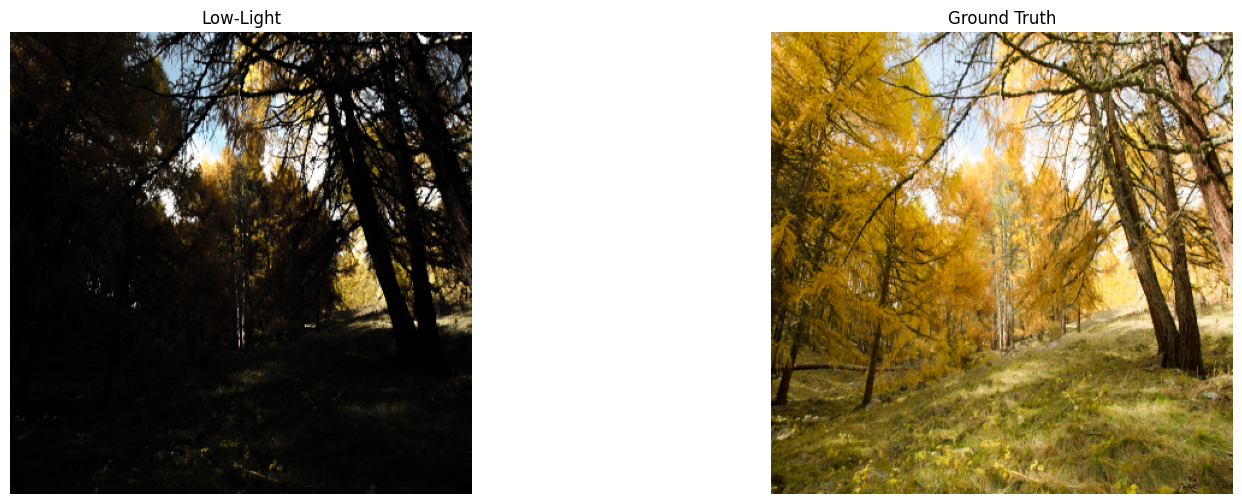

In [76]:
show_images(
    [low_img, high_img],
    ["Low-Light", "Ground Truth"]
)

In [77]:
# histogram-equilizer

In [78]:
gray_low = cv2.cvtColor(low_img, cv2.COLOR_RGB2GRAY)

In [79]:
gray_high = cv2.cvtColor(high_img, cv2.COLOR_RGB2GRAY)

In [80]:
hist_eq = cv2.equalizeHist(gray_low)

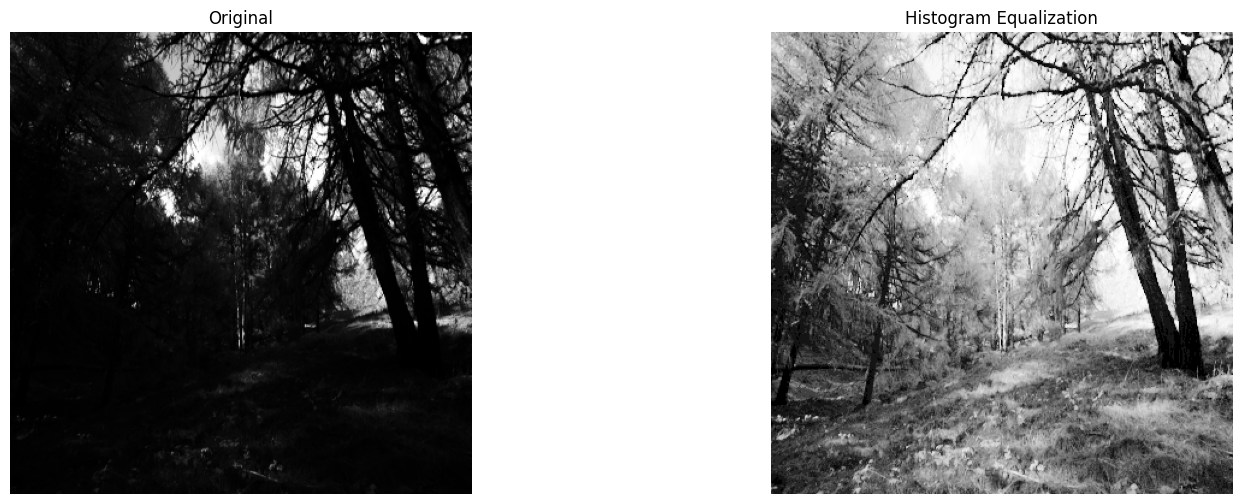

In [81]:
show_images(
    [gray_low, hist_eq],
    ["Original", "Histogram Equalization"]
)

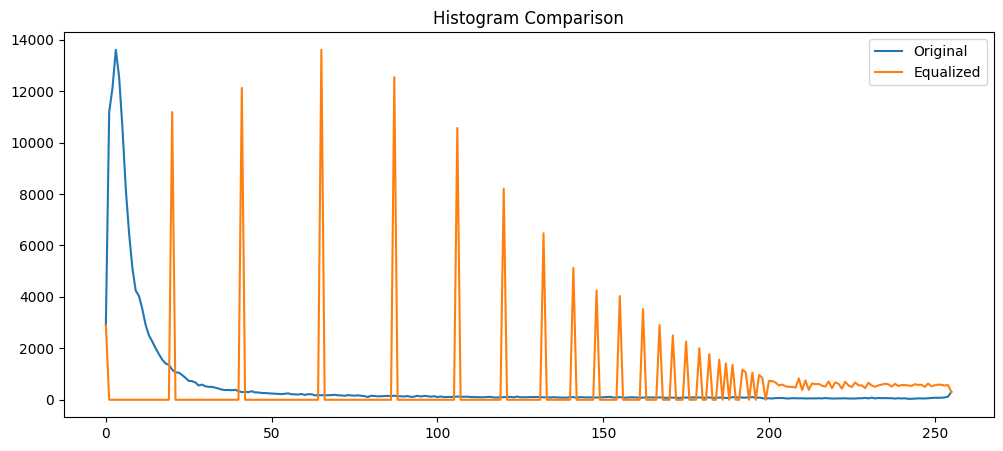

In [82]:
hist_original = cv2.calcHist(
    [gray_low],
    [0],
    None,
    [256],
    [0,256]
)

hist_eq_hist = cv2.calcHist(
    [hist_eq],
    [0],
    None,
    [256],
    [0,256]
)

plt.figure(figsize=(12,5))

plt.plot(hist_original, label="Original")
plt.plot(hist_eq_hist, label="Equalized")

plt.legend()
plt.title("Histogram Comparison")

plt.show()

In [83]:
# clahe

In [84]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

In [85]:
clahe_img = clahe.apply(gray_low)

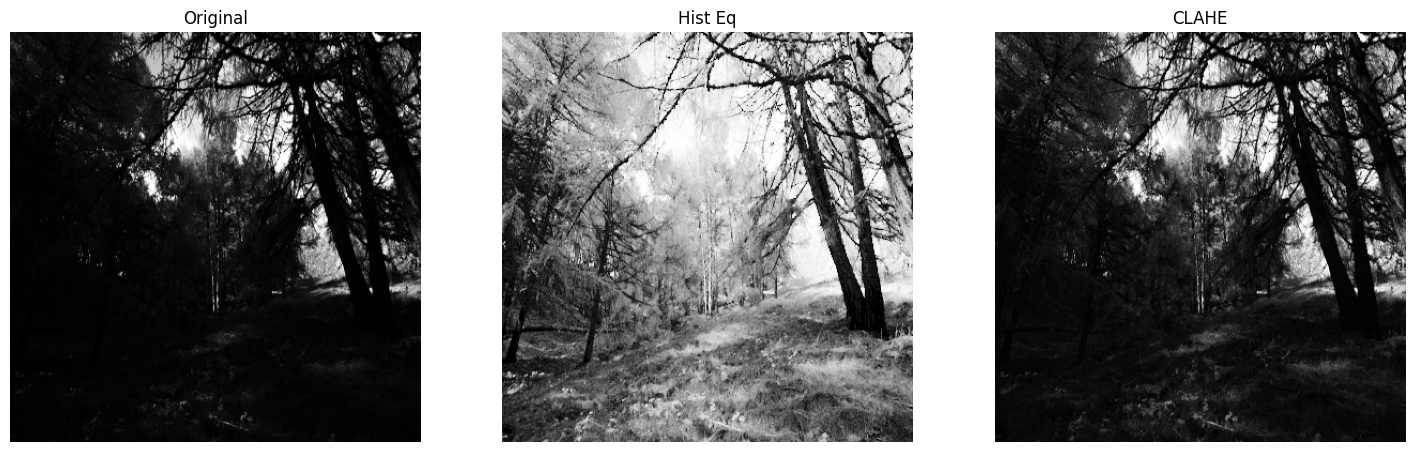

In [86]:
show_images(
    [gray_low, hist_eq, clahe_img],
    ["Original", "Hist Eq", "CLAHE"]
)

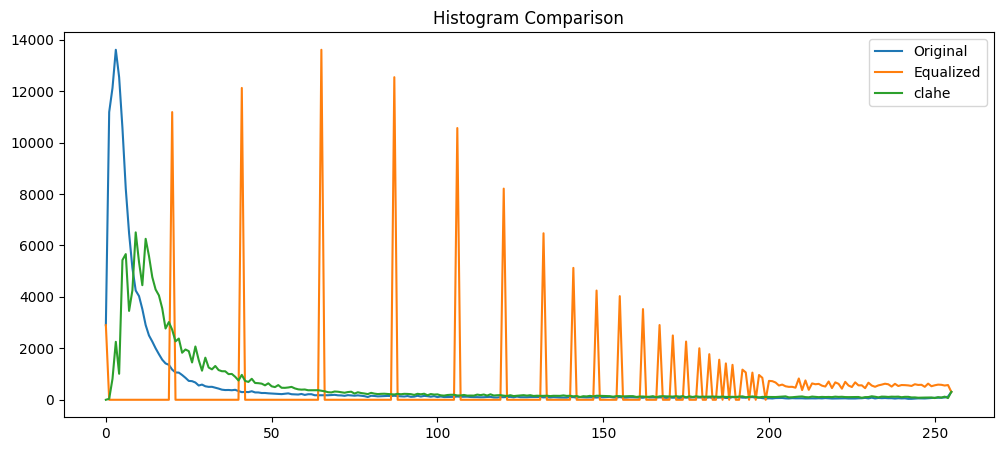

In [87]:
hist_original = cv2.calcHist(
    [gray_low],
    [0],
    None,
    [256],
    [0,256]
)

hist_eq_hist = cv2.calcHist(
    [hist_eq],
    [0],
    None,
    [256],
    [0,256]
)

hist_clahe = cv2.calcHist(
    [clahe_img],
    [0],
    None,
    [256],
    [0,256]
)


plt.figure(figsize=(12,5))

plt.plot(hist_original, label="Original")
plt.plot(hist_eq_hist, label="Equalized")
plt.plot(hist_clahe ,label="clahe")

plt.legend()
plt.title("Histogram Comparison")

plt.show()

In [88]:
# gamma correction

In [89]:
# (I_out) = (I_in)^(y)

# y < 1 ==> brighten
# y > 1 ==> darken

In [90]:
# (0 - 255) -> (0 - 1)

In [91]:
normalized = low_img / 255.0

In [92]:
gamma = 0.5

In [93]:
gamma_corrected = np.power(normalized, gamma)

In [94]:
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

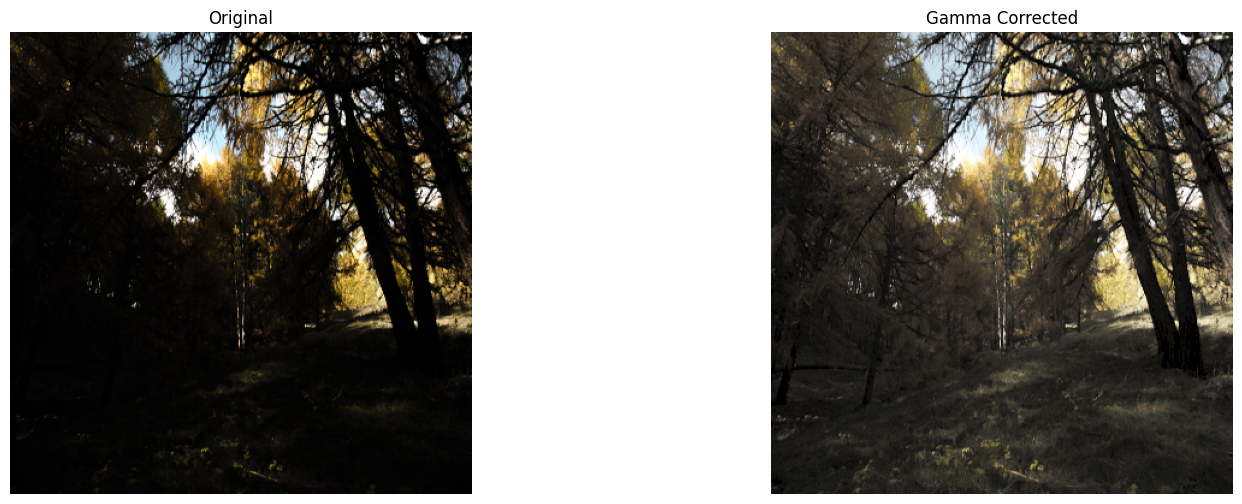

In [95]:
show_images(
    [low_img, gamma_corrected],
    ["Original", "Gamma Corrected"]
)

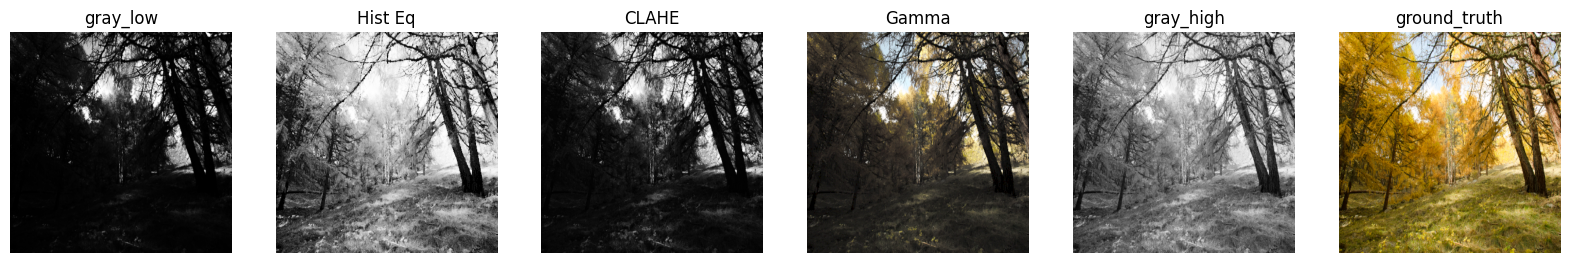

In [96]:
show_images(

    [
        gray_low,
        hist_eq,
        clahe_img,
        gamma_corrected,
        gray_high,
        high_img
    ],

    [
        "gray_low",
        "Hist Eq",
        "CLAHE",
        "Gamma",
        "gray_high",
        "ground_truth"
    ],

    figsize=(20,6)
)

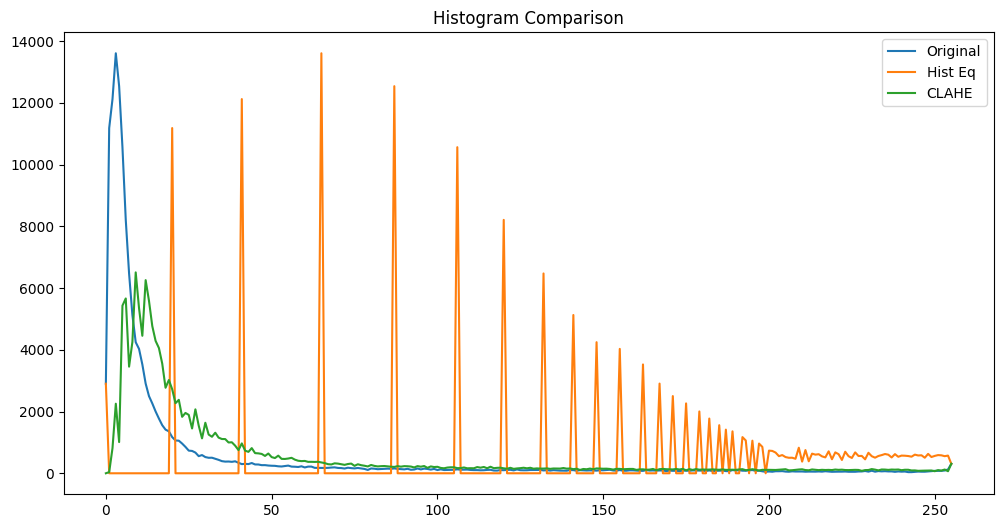

In [97]:
methods = {

    "Original": gray_low,
    "Hist Eq": hist_eq,
    "CLAHE": clahe_img
}

plt.figure(figsize=(12,6))

for name, img in methods.items():

    hist = cv2.calcHist(
        [img],
        [0],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist, label=name)

plt.legend()
plt.title("Histogram Comparison")

plt.show()

In [98]:
def mean_brightness(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    return np.mean(img)

In [99]:
results = {

    "Original": mean_brightness(gray_low),
    "Hist Eq": mean_brightness(hist_eq),
    "CLAHE": mean_brightness(clahe_img),
    "Gamma": mean_brightness(gamma_corrected),
    "Ground Truth": mean_brightness(high_img)
}

results

{'Original': np.float64(26.833231608072918),
 'Hist Eq': np.float64(130.6693861219618),
 'CLAHE': np.float64(44.324381510416664),
 'Gamma': np.float64(61.57562934027778),
 'Ground Truth': np.float64(122.38170030381944)}

In [100]:
def contrast(img):

    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    return np.std(img)

In [101]:
contrast_results = {

    "Original": contrast(gray_low),
    "Hist Eq": contrast(hist_eq),
    "CLAHE": contrast(clahe_img),
    "Gamma": contrast(gamma_corrected),
    "Ground Truth": contrast(high_img)
}

contrast_results

{'Original': np.float64(49.55534568773556),
 'Hist Eq': np.float64(71.00568211906788),
 'CLAHE': np.float64(56.55081266557923),
 'Gamma': np.float64(54.19731408262403),
 'Ground Truth': np.float64(54.70500094350386)}

In [102]:
comparison = pd.DataFrame({

    "Method": list(results.keys()),

    "Brightness": list(results.values()),

    "Contrast": list(contrast_results.values())

})

comparison

,Method,Brightness,Contrast
0,Original,26.833232,49.555346
1,Hist Eq,130.669386,71.005682
2,CLAHE,44.324382,56.550813
3,Gamma,61.575629,54.197314
4,Ground Truth,122.381700,54.705001


In [103]:
high_img.shape

(384, 384, 3)

In [104]:
gray_high

array([[153, 153, 151, ...,  97,  92, 156],
       [153, 167, 149, ..., 107,  87, 122],
       [171, 161, 174, ...,  65,  72,  89],
       ...,
       [ 62,  44,  40, ...,  61,  59,  73],
       [ 65,  63,  47, ...,  69,  61,  69],
       [ 85,  69,  52, ...,  72,  62,  51]], shape=(384, 384), dtype=uint8)